In [1]:
import pandas as pd
import numpy as np

output_columns= ["X", "Y", "Z"]
df_gnd = pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[output_columns]
df_pred = pd.read_csv("./predictions/gps_log_d/rss_n=50_noise=0.0_seed=1.csv")



In [2]:
output_columns= ["X", "Y", "Z"]
df_gnd = pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[output_columns]
df_pred = pd.read_csv("./predictions/gps_log_d/rss_n=50_noise=0.0_seed=1.csv")

def compute_difference_norms(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    difference_df = pd.DataFrame()
    difference_df['diff_X'] = df1['X'] - df2['X']
    difference_df['diff_Y'] = df1['Y'] - df2['Y']
    difference_df['diff_Z'] = df1['Z'] - df2['Z']
    difference_df['error_norm'] = np.sqrt(
        difference_df['diff_X']**2 + difference_df['diff_Y']**2 + difference_df['diff_Z']**2
    )
    return difference_df["error_norm"]
df_diff = compute_difference_norms(df_gnd, df_pred)
print(df_diff.head())

def summarize_errors(error_series: pd.Series):
    min_error = error_series.min()
    max_error = error_series.max()
    mean_error = error_series.mean()
    mean_error_squared = np.mean(error_series ** 2)
    median_error = error_series.quantile(0.50)
    p90_error = error_series.quantile(0.90)
    return [min_error, max_error, mean_error, mean_error_squared, median_error, p90_error]

results = summarize_errors(df_diff)
print("Min Error:", results[0])
print("Max Error:", results[1])
print("Mean Error:", results[2])
print("Mean of Error^2:", results[3])
print("Median (50%ile) Error:", results[4])
print("90%ile Error:", results[5])

def load_errors_for_all_seeds(base_path: str, df_gnd: pd.DataFrame) -> pd.DataFrame:
    error_dict = {}
    for seed in range(10):
        csv_path = f"{base_path}{seed}.csv"
        df_pred = pd.read_csv(csv_path)
        error_series = compute_difference_norms(df_gnd, df_pred)
        error_dict[f"seed_{seed}"] = error_series
    df_all_errors = pd.DataFrame(error_dict)
    return df_all_errors

base_path = "./predictions/gps_log_d/rss_n=50_noise=0.0_seed="
df_all_seed_errors = load_errors_for_all_seeds(base_path, df_gnd)
print(df_all_seed_errors.head())
def summarize_all_seed_errors(df_all_seed_errors: pd.DataFrame) -> pd.DataFrame:
    summary_dict = {}
    for seed_col in df_all_seed_errors.columns:
        error_series = df_all_seed_errors[seed_col]
        stats = summarize_errors(error_series)
        summary_dict[seed_col] = stats
    summary_df = pd.DataFrame(summary_dict, index=[
        'min_error', 'max_error', 'mean_error', 'mean_error_squared', 'median_error', 'p90_error'
    ]).T
    return summary_df
base_path = "./predictions/gps_log_d/rss_n=50_noise=0.0_seed="
df_all_seed_errors = load_errors_for_all_seeds(base_path, df_gnd)
summary_df = summarize_all_seed_errors(df_all_seed_errors)
print(summary_df)
def cdf_at_threshold(error_series: pd.Series, threshold: float) -> float:

    count_below_threshold = (error_series <= threshold).sum()
    total_count = len(error_series)
    cdf_value = (count_below_threshold / total_count) * 100.0
    return cdf_value
df_diff = compute_difference_norms(df_gnd, df_pred)
pct_below_o1 = cdf_at_threshold(df_diff, 0.1)
print(f"Percentage of errors <= 0.1: {pct_below_o1:.2f}%")
pct_below_o5 = cdf_at_threshold(df_diff, 0.5)
pct_below_1_0 = cdf_at_threshold(df_diff, 1.0)
def cdf_at_threshold_for_all_seeds(df_all_seed_errors: pd.DataFrame, threshold: float) -> pd.Series:
    cdf_values = {}
    for seed_col in df_all_seed_errors.columns:
        error_series = df_all_seed_errors[seed_col]
        count_below_threshold = (error_series <= threshold).sum()
        total_count = len(error_series)
        cdf_value = (count_below_threshold / total_count) * 100.0
        cdf_values[seed_col] = cdf_value
    return pd.Series(cdf_values, name=f"CDF_at_{threshold}")
threshold = 0.1
cdf_series = cdf_at_threshold_for_all_seeds(df_all_seed_errors, threshold)
print(f"CDF (Pct of errors <= {threshold}) per seed:")
print(cdf_series)




0    0.006806
1    0.015717
2    0.036378
3    0.057028
4    0.078111
Name: error_norm, dtype: float64
Min Error: 0.00016909017096657154
Max Error: 2.6770994153261887
Mean Error: 0.11344835600768728
Mean of Error^2: 0.05067145520868954
Median (50%ile) Error: 0.04632336837674736
90%ile Error: 0.27274001174497775
     seed_0    seed_1    seed_2    seed_3    seed_4    seed_5    seed_6  \
0  0.000027  0.006806  0.014109  0.006321  0.049849  0.004743  0.058359   
1  0.015375  0.015717  0.018380  0.012524  0.034656  0.011764  0.043672   
2  0.030319  0.036378  0.037998  0.029640  0.022200  0.027702  0.030128   
3  0.044733  0.057028  0.059067  0.046538  0.017300  0.043551  0.019373   
4  0.060165  0.078111  0.081412  0.063601  0.024681  0.059251  0.016641   

     seed_7    seed_8    seed_9  
0  0.000064  0.022734  0.000049  
1  0.016269  0.009563  0.021103  
2  0.032295  0.037233  0.041677  
3  0.047906  0.066689  0.061572  
4  0.062529  0.097205  0.082560  
        min_error  max_error  me

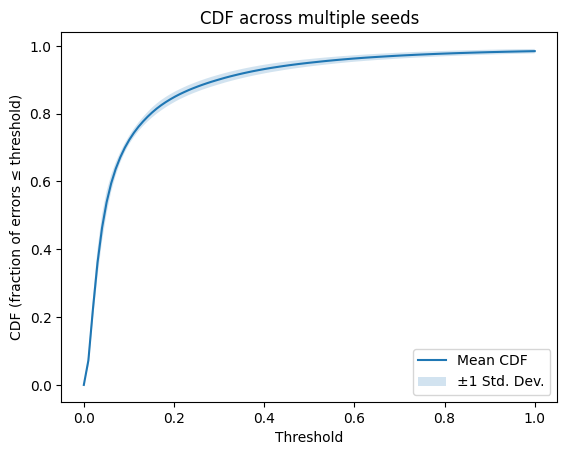

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mean_std_cdf(df_all_seed_errors: pd.DataFrame, 
                      min_threshold: float = 0.0, 
                      max_threshold: float = 1.0,
                      num_points: int = 100) -> None:

    # Create an array of thresholds from min_threshold to max_threshold
    thresholds = np.linspace(min_threshold, max_threshold, num_points)

    # Prepare lists to store the mean and std at each threshold
    mean_cdf_vals = []
    std_cdf_vals = []

    # Iterate over each threshold
    for t in thresholds:
        # For each seed column, compute fraction of errors <= t
        cdf_values_per_seed = []
        for seed_col in df_all_seed_errors.columns:
            seed_errors = df_all_seed_errors[seed_col]
            fraction_leq_t = (seed_errors <= t).mean()  # fraction <= threshold
            cdf_values_per_seed.append(fraction_leq_t)

        # Compute mean and std across all seeds for this threshold
        mean_cdf = np.mean(cdf_values_per_seed)
        std_cdf = np.std(cdf_values_per_seed)
        mean_cdf_vals.append(mean_cdf)
        std_cdf_vals.append(std_cdf)

    # Convert lists to NumPy arrays for plotting
    mean_cdf_vals = np.array(mean_cdf_vals)
    std_cdf_vals = np.array(std_cdf_vals)

    # Plot the mean curve
    plt.plot(thresholds, mean_cdf_vals, label="Mean CDF")


    plt.fill_between(thresholds, 
                     mean_cdf_vals - std_cdf_vals, 
                     mean_cdf_vals + std_cdf_vals, 
                     alpha=0.2, 
                     label="±1 Std. Dev.")


    plt.xlabel("Threshold")
    plt.ylabel("CDF (fraction of errors ≤ threshold)")
    plt.title("CDF across multiple seeds")
    plt.legend()
    plt.show()

plot_mean_std_cdf(df_all_seed_errors, 
                  min_threshold=0.0, 
                  max_threshold=1.0, 
                  num_points=100)



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.lines as mlines

def compute_difference_norms(df1, df2):
    d = pd.DataFrame()
    d['diff_X'] = df1['X'] - df2['X']
    d['diff_Y'] = df1['Y'] - df2['Y']
    d['diff_Z'] = df1['Z'] - df2['Z']
    d['error_norm'] = np.sqrt(d['diff_X']**2 + d['diff_Y']**2 + d['diff_Z']**2)
    return d['error_norm']

def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

@interact(n=widgets.IntSlider(value=50, min=50, max=1500, step=50))
def show_all_models(n):
    df_gnd = load_ground_truth()
    patterns = {
        ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
        ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
        ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
        ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
        ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
        ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
        ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
        ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
        ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
    }
    styles = {
        ("gps","absolute"):   ("blue","-"),
        ("gps","relative"):   ("purple","-"),
        ("gps","log_d"):      ("green","-"),
        ("nns","absolute"):   ("blue","--"),
        ("nns","relative"):   ("purple","--"),
        ("nns","log_d"):      ("green","--"),
        ("KANs","absolute"):  ("blue","-."),
        ("KANs","relative"):  ("purple","-."),
        ("KANs","log_d"):     ("green","-.")
    }
    plt.figure(figsize=(10,6))
    thresholds = np.linspace(0,1,100)
    for (m,r), pattern in patterns.items():
        df_all = pd.DataFrame()
        base_dir = f"./predictions/{m}_{r}/"
        for seed in range(10):
            path = base_dir + pattern.format(n=n, seed=seed)
            df_pred = pd.read_csv(path)
            err = compute_difference_norms(df_gnd, df_pred)
            df_all[f"seed_{seed}"] = err
        mean_cdf = []
        for t in thresholds:
            mean_cdf.append((df_all <= t).mean(axis=0).mean())
        c,l = styles[(m,r)]
        plt.plot(thresholds, mean_cdf, color=c, linestyle=l, label=f"{m}_{r}")
    c_abs = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', label='absolute')
    c_rel = mlines.Line2D([], [], color='purple', marker='s', linestyle='None', label='relative')
    c_log = mlines.Line2D([], [], color='green', marker='s', linestyle='None', label='log_d')
    l_gps = mlines.Line2D([], [], color='black', linestyle='-', label='gps')
    l_nns = mlines.Line2D([], [], color='black', linestyle='--', label='nns')
    l_kan = mlines.Line2D([], [], color='black', linestyle='-.', label='KANs')
    plt.xlabel("Threshold")
    plt.ylabel("CDF (fraction of errors <= threshold)")
    plt.title("All Models CDF")
    leg_elems = [c_abs, l_gps, c_rel, l_nns, c_log, l_kan]
    plt.legend(handles=leg_elems, loc='lower right', ncol=2)
    plt.show()


interactive(children=(IntSlider(value=50, description='n', max=1500, min=50, step=50), Output()), _dom_classes…

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.lines as mlines

current_fig = None
current_n = 50  # default to 50

def compute_difference_norms(df1, df2):
    d = pd.DataFrame()
    d['diff_X'] = df1['X'] - df2['X']
    d['diff_Y'] = df1['Y'] - df2['Y']
    d['diff_Z'] = df1['Z'] - df2['Z']
    d['error_norm'] = np.sqrt(d['diff_X']**2 + d['diff_Y']**2 + d['diff_Z']**2)
    return d['error_norm']

def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

def gradient_fill_cdf(x, mean_cdf, std_cdf, color, layers=5, max_alpha=0.02):
    ax = plt.gca()
    for i in range(layers):
        f1 = i / layers
        f2 = (i + 1) / layers
        alpha_layer = max_alpha * (1 - f1)
        lower1 = mean_cdf - f1*std_cdf
        lower2 = mean_cdf - f2*std_cdf
        upper1 = mean_cdf + f1*std_cdf
        upper2 = mean_cdf + f2*std_cdf
        ax.fill_between(x, lower1, lower2, color=color, alpha=alpha_layer)
        ax.fill_between(x, upper1, upper2, color=color, alpha=alpha_layer)

patterns = {
    ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
}

styles = {
    ("gps","absolute"):   ("blue","-"),
    ("gps","relative"):   ("purple","-"),
    ("gps","log_d"):      ("green","-"),
    ("nns","absolute"):   ("blue","--"),
    ("nns","relative"):   ("purple","--"),
    ("nns","log_d"):      ("green","--"),
    ("KANs","absolute"):  ("blue","-."),
    ("KANs","relative"):  ("purple","-."),
    ("KANs","log_d"):     ("green","-.")
}

def on_save_plot_clicked(_):
    global current_fig, current_n
    if current_fig is not None:
        filename = f"cdf_plot_n={current_n}.svg"
        current_fig.savefig(filename)
        print(f"Plot saved as {filename}")
    else:
        print("No plot to save yet.")

save_button = widgets.Button(description="Save Plot")
save_button.on_click(on_save_plot_clicked)

@interact(n=widgets.IntSlider(value=50, min=50, max=1500, step=50))
def show_all_models(n):
    global current_fig, current_n
    current_n = n
    df_gnd = load_ground_truth()
    thresholds = np.linspace(0, 1, 100)

    plt.figure(figsize=(10,6))
    for (m,r), pattern in patterns.items():
        base_dir = f"./predictions/{m}_{r}/"
        df_all = pd.DataFrame()
        for seed in range(10):
            path = base_dir + pattern.format(n=n, seed=seed)
            df_pred = pd.read_csv(path)
            err = compute_difference_norms(df_gnd, df_pred)
            df_all[f"seed_{seed}"] = err

        mean_cdf, std_cdf = [], []
        for t in thresholds:
            vals = (df_all <= t).mean(axis=0)
            mean_cdf.append(vals.mean())
            std_cdf.append(vals.std())

        mean_cdf = np.array(mean_cdf)
        std_cdf  = np.array(std_cdf)
        c, line_style = styles[(m,r)]
        plt.plot(thresholds, mean_cdf, color=c, linestyle=line_style, label=f"{m}_{r}")
        gradient_fill_cdf(thresholds, mean_cdf, std_cdf, c, layers=5, max_alpha=0.05)

    c_abs = mlines.Line2D([], [], color='blue',  marker='s', linestyle='None', label='absolute')
    c_rel = mlines.Line2D([], [], color='purple',marker='s', linestyle='None', label='relative')
    c_log = mlines.Line2D([], [], color='green', marker='s', linestyle='None', label='log_d')
    l_gps = mlines.Line2D([], [], color='black', linestyle='-',  label='gps')
    l_nns = mlines.Line2D([], [], color='black', linestyle='--', label='nns')
    l_kan = mlines.Line2D([], [], color='black', linestyle='-.', label='KANs')
    plt.xlabel("Error (m)")
    plt.ylabel("CDF of Error")
    plt.title(f"The CDF of model Errors with {n} training samples")
    leg_elems = [c_abs, c_rel, c_log, l_gps, l_nns, l_kan]
    plt.legend(handles=leg_elems, loc='lower right', ncol=2)

    current_fig = plt.gcf()
    plt.show()

display(save_button)


interactive(children=(IntSlider(value=50, description='n', max=1500, min=50, step=50), Output()), _dom_classes…

Button(description='Save Plot', style=ButtonStyle())

Plot saved as p90_vs_n.svg


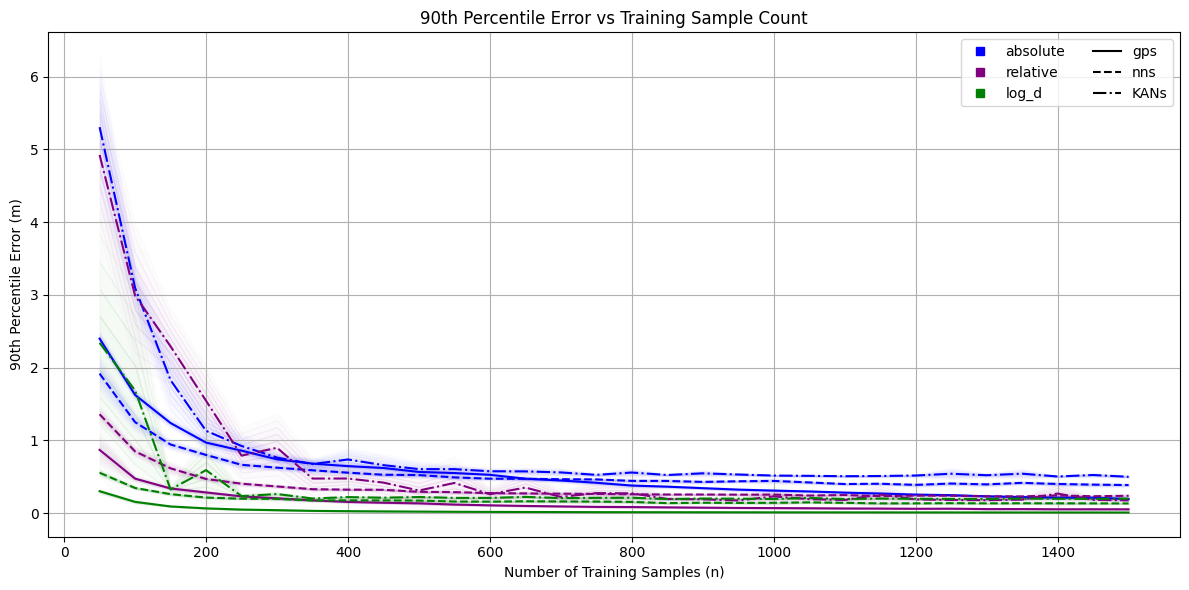

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def compute_difference_norms(df1, df2):
    d = pd.DataFrame()
    d['diff_X'] = df1['X'] - df2['X']
    d['diff_Y'] = df1['Y'] - df2['Y']
    d['diff_Z'] = df1['Z'] - df2['Z']
    d['error_norm'] = np.sqrt(d['diff_X']**2 + d['diff_Y']**2 + d['diff_Z']**2)
    return d['error_norm']

def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

def gradient_fill(x, mean, std, color, layers=5, max_alpha=0.05):
    ax = plt.gca()
    for i in range(layers):
        f1 = i / layers
        f2 = (i + 1) / layers
        alpha = max_alpha * (1 - f1)
        upper1 = mean + f1 * std
        upper2 = mean + f2 * std
        lower1 = mean - f1 * std
        lower2 = mean - f2 * std
        ax.fill_between(x, lower1, lower2, color=color, alpha=alpha)
        ax.fill_between(x, upper1, upper2, color=color, alpha=alpha)

patterns = {
    ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
}

styles = {
    ("gps","absolute"):   ("blue","-"),
    ("gps","relative"):   ("purple","-"),
    ("gps","log_d"):      ("green","-"),
    ("nns","absolute"):   ("blue","--"),
    ("nns","relative"):   ("purple","--"),
    ("nns","log_d"):      ("green","--"),
    ("KANs","absolute"):  ("blue","-."),
    ("KANs","relative"):  ("purple","-."),
    ("KANs","log_d"):     ("green","-.")
}

gnd = load_ground_truth()
n_values = list(range(50, 1501, 50))
cached_errors = {}

plt.figure(figsize=(12, 6))

for (m, r), pattern in patterns.items():
    p90_means = []
    p90_stds = []
    for n in n_values:
        key = (m, r, n)
        if key not in cached_errors:
            seed_errors = []
            for seed in range(10):
                pred_path = f"./predictions/{m}_{r}/" + pattern.format(n=n, seed=seed)
                df_pred = pd.read_csv(pred_path)
                error = compute_difference_norms(gnd, df_pred)
                p90 = np.percentile(error, 90)
                seed_errors.append(p90)
            cached_errors[key] = seed_errors
        else:
            seed_errors = cached_errors[key]
        p90_means.append(np.mean(seed_errors))
        p90_stds.append(np.std(seed_errors))
    p90_means = np.array(p90_means)
    p90_stds = np.array(p90_stds)
    color, linestyle = styles[(m, r)]
    plt.plot(n_values, p90_means, color=color, linestyle=linestyle, label=f"{m}_{r}")
    gradient_fill(n_values, p90_means, p90_stds, color=color, layers=5, max_alpha=0.05)

c_abs = mlines.Line2D([], [], color='blue',  marker='s', linestyle='None', label='absolute')
c_rel = mlines.Line2D([], [], color='purple',marker='s', linestyle='None', label='relative')
c_log = mlines.Line2D([], [], color='green', marker='s', linestyle='None', label='log_d')
l_gps = mlines.Line2D([], [], color='black', linestyle='-',  label='gps')
l_nns = mlines.Line2D([], [], color='black', linestyle='--', label='nns')
l_kan = mlines.Line2D([], [], color='black', linestyle='-.', label='KANs')

plt.xlabel("Number of Training Samples (n)")
plt.ylabel("90th Percentile Error (m)")
plt.title("90th Percentile Error vs Training Sample Count")
plt.legend(handles=[c_abs, c_rel, c_log, l_gps, l_nns, l_kan], loc="upper right", ncol=2)
plt.grid(True)
plt.tight_layout()

# Save the figure as SVG
plt.savefig("p90_vs_n.svg", format="svg")
print("Plot saved as p90_vs_n.svg")

plt.show()


In [7]:
import numpy as np
import pandas as pd

def compute_difference_norms(df1, df2):
    d = pd.DataFrame()
    d['diff_X'] = df1['X'] - df2['X']
    d['diff_Y'] = df1['Y'] - df2['Y']
    d['diff_Z'] = df1['Z'] - df2['Z']
    d['error_norm'] = np.sqrt(d['diff_X']**2 + d['diff_Y']**2 + d['diff_Z']**2)
    return d['error_norm']

def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

patterns = {
    ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
}

gnd = load_ground_truth()
n = 250
cached_errors = {}
table_rows = []

for (m, r), pattern in patterns.items():
    model_name = f"{m}_{r}"
    key = (m, r, n)
    if key not in cached_errors:
        seed_errors = []
        for seed in range(10):
            pred_path = f"./predictions/{m}_{r}/" + pattern.format(n=n, seed=seed)
            df_pred = pd.read_csv(pred_path)
            error = compute_difference_norms(gnd, df_pred)
            seed_errors.append(error)
        cached_errors[key] = seed_errors
    else:
        seed_errors = cached_errors[key]
    
    all_errors = pd.concat(seed_errors, axis=0)  # stack all seed errors
    row = {
        "Model_Type": model_name,
        "90th_percentile": round(np.percentile(all_errors, 90), 4),
        "50th_percentile": round(np.percentile(all_errors, 50), 4),
        "mean_error": round(all_errors.mean(), 4)
    }
    table_rows.append(row)

# Create and save the dataframe
df_out = pd.DataFrame(table_rows)
df_out.set_index("Model_Type", inplace=True)
df_out.to_csv("error_summary_n250_clean.csv")

print("Saved clean error table to error_summary_n50_clean.csv")


Saved clean error table to error_summary_n50_clean.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.lines as mlines
from pathlib import Path

# ────────── GLOBAL STYLING ──────────
sns.set(style="whitegrid", context="notebook")
grey_bg = "#f0f0f0"

mpl.rcParams.update({
    "axes.facecolor": grey_bg,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

palette = {
    "absolute": (65/255, 105/255, 225/255),   # royal blue
    "relative": (159/255, 136/255, 117/255),  # muted brown
    "log_d":    (252/255, 167/255,  10/255)   # orange
}
styles = {
    ("gps",  "absolute"):  (palette["absolute"], "-"),
    ("gps",  "relative"):  (palette["relative"], "-"),
    ("gps",  "log_d"):     (palette["log_d"],    "-"),
    ("nns",  "absolute"):  (palette["absolute"], "--"),
    ("nns",  "relative"):  (palette["relative"], "--"),
    ("nns",  "log_d"):     (palette["log_d"],    "--"),
    ("KANs", "absolute"):  (palette["absolute"], "-."),
    ("KANs", "relative"):  (palette["relative"], "-."),
    ("KANs", "log_d"):     (palette["log_d"],    "-.")
}

# ────────── DATA HELPERS ──────────
def compute_difference_norms(df1, df2):
    return np.linalg.norm(df1[["X","Y","Z"]].values - df2[["X","Y","Z"]].values, axis=1)

def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

def gradient_fill_cdf(x, mean, std, color, layers=5, max_alpha=0.08):  # <-- denser shading
    ax = plt.gca()
    for i in range(layers):
        f1, f2  = i/layers, (i+1)/layers
        alpha   = max_alpha * (1 - f1)
        ax.fill_between(x, mean - f2*std, mean - f1*std, color=color, alpha=alpha)
        ax.fill_between(x, mean + f1*std, mean + f2*std, color=color, alpha=alpha)

patterns = {
    ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
}

# ────────── PLOTTING CORE ──────────
def make_cdf_plot(n, show=False, save=False, out_dir=Path(".")):
    df_gnd      = load_ground_truth()
    thresholds  = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor(grey_bg)
    ax.grid(True)

    for (model, rep), pattern in patterns.items():
        df_all = pd.DataFrame()
        base   = f"./predictions/{model}_{rep}/"
        for seed in range(10):
            path = base + pattern.format(n=n, seed=seed)
            df_all[f"seed{seed}"] = compute_difference_norms(df_gnd, pd.read_csv(path))

        mean = df_all.apply(lambda col: [(col <= t).mean() for t in thresholds],
                            axis=0).mean(axis=1).values
        std  = df_all.apply(lambda col: [(col <= t).mean() for t in thresholds],
                            axis=0).std(axis=1).values
        color, ls = styles[(model, rep)]
        ax.plot(thresholds, mean, color=color, linestyle=ls)
        gradient_fill_cdf(thresholds, mean, std, color)

    # custom legend
    c_abs = mlines.Line2D([], [], color=palette["absolute"], marker='s',
                          linestyle='None', label='Absolute')
    c_rel = mlines.Line2D([], [], color=palette["relative"], marker='s',
                          linestyle='None', label='Relative')
    c_log = mlines.Line2D([], [], color=palette["log_d"],    marker='s',
                          linestyle='None', label='LogD')
    l_gps = mlines.Line2D([], [], color='black', linestyle='-',  label='GPs')
    l_nns = mlines.Line2D([], [], color='black', linestyle='--', label='NNs')
    l_kan = mlines.Line2D([], [], color='black', linestyle='-.', label='KANs')
    ax.legend(handles=[c_abs, c_rel, c_log, l_gps, l_nns, l_kan],
              loc='lower right', ncol=2)

    ax.set_xlabel("Error (m)")
    ax.set_ylabel("CDF of Error")
    ax.set_title(f"CDF of Model Errors with {n} Training Samples")

    if save:
        fname = out_dir / f"cdf_plot_n={n:04d}.svg"
        fig.savefig(fname, bbox_inches="tight")
        print(f"saved {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

# ────────── INTERACTIVE VIEW (unchanged) ──────────
@interact(n=widgets.IntSlider(value=50, min=50, max=1500, step=50))
def show_all_models(n):
    make_cdf_plot(n, show=True, save=False)

# ────────── BATCH SAVE HELPER ──────────
def save_all_plots(start=50, stop=1500, step=50, out_dir="plots"):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    for n in range(start, stop + 1, step):
        make_cdf_plot(n, show=False, save=True, out_dir=out_path)

# call `save_all_plots()` when you’re ready
# generate & save every plot (50, 100, …, 1500) into ./plots/
save_all_plots()

# if you really meant only 50 and 1500:
# save_all_plots(start=50, stop=1500, step=1450)


interactive(children=(IntSlider(value=50, description='n', max=1500, min=50, step=50), Output()), _dom_classes…

saved plots/cdf_plot_n=0050.svg
saved plots/cdf_plot_n=0100.svg
saved plots/cdf_plot_n=0150.svg
saved plots/cdf_plot_n=0200.svg
saved plots/cdf_plot_n=0250.svg
saved plots/cdf_plot_n=0300.svg
saved plots/cdf_plot_n=0350.svg
saved plots/cdf_plot_n=0400.svg
saved plots/cdf_plot_n=0450.svg
saved plots/cdf_plot_n=0500.svg
saved plots/cdf_plot_n=0550.svg
saved plots/cdf_plot_n=0600.svg
saved plots/cdf_plot_n=0650.svg
saved plots/cdf_plot_n=0700.svg
saved plots/cdf_plot_n=0750.svg
saved plots/cdf_plot_n=0800.svg
saved plots/cdf_plot_n=0850.svg
saved plots/cdf_plot_n=0900.svg
saved plots/cdf_plot_n=0950.svg
saved plots/cdf_plot_n=1000.svg
saved plots/cdf_plot_n=1050.svg
saved plots/cdf_plot_n=1100.svg
saved plots/cdf_plot_n=1150.svg
saved plots/cdf_plot_n=1200.svg
saved plots/cdf_plot_n=1250.svg
saved plots/cdf_plot_n=1300.svg
saved plots/cdf_plot_n=1350.svg
saved plots/cdf_plot_n=1400.svg
saved plots/cdf_plot_n=1450.svg
saved plots/cdf_plot_n=1500.svg


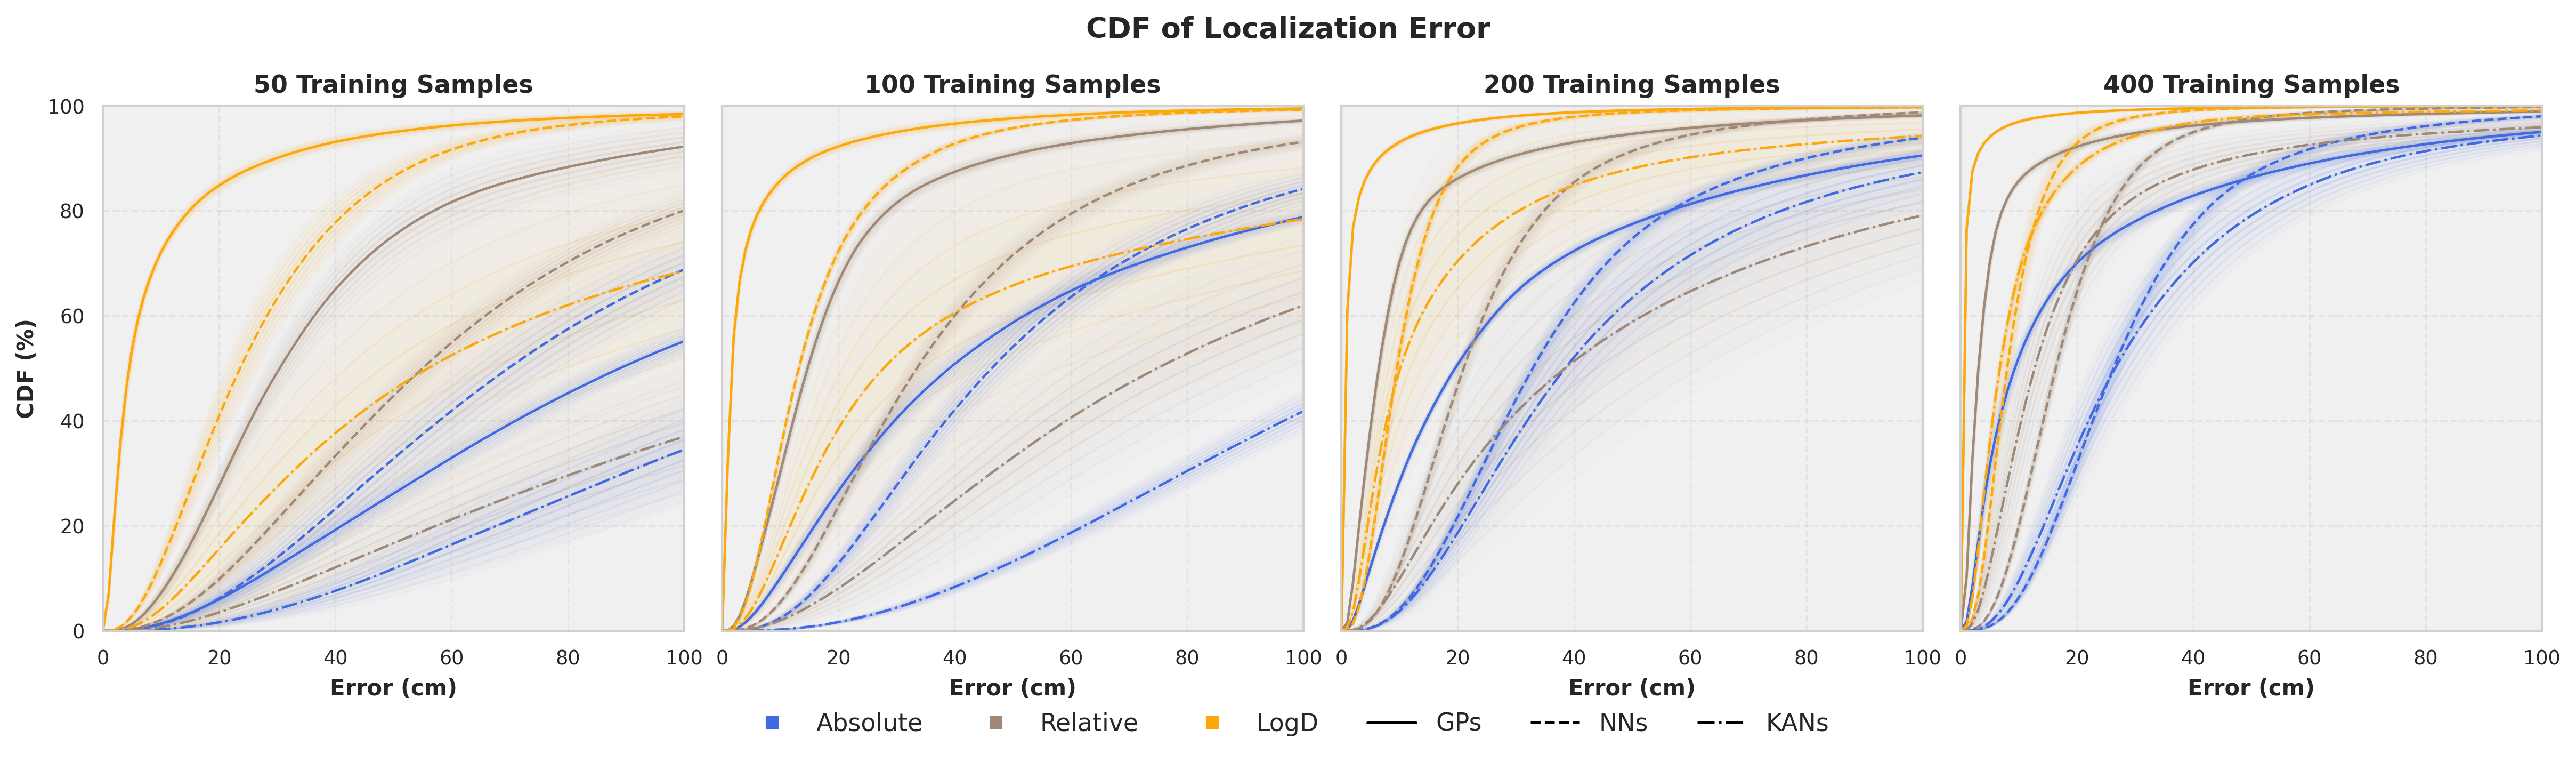

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from pathlib import Path


# ─── visual style (shared across all paper figures) ─────────────────────────
sns.set(style="whitegrid", context="paper")         # same as box-plots
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG  = "#f0f0f0"          # single source of truth for the light-grey bg
grey_bg = AX_BG             # keep old variable name alive

# colour / style dictionaries stay unchanged
palette = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255)
}
styles = {
    ("gps",  "absolute"):  (palette["absolute"], "-"),
    ("gps",  "relative"):  (palette["relative"], "-"),
    ("gps",  "log_d"):     (palette["log_d"],    "-"),
    ("nns",  "absolute"):  (palette["absolute"], "--"),
    ("nns",  "relative"):  (palette["relative"], "--"),
    ("nns",  "log_d"):     (palette["log_d"],    "--"),
    ("KANs", "absolute"):  (palette["absolute"], "-.") ,
    ("KANs", "relative"):  (palette["relative"], "-.") ,
    ("KANs", "log_d"):     (palette["log_d"],    "-.")
}
patterns = {
    ("gps","absolute"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","relative"):   "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps","log_d"):      "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns","absolute"):   "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","relative"):   "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns","log_d"):      "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs","absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs","log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv"
}

def compute_difference_norms(df1, df2):
    """ ℓ2 distance between point-cloud rows."""
    return np.linalg.norm(df1[["X","Y","Z"]].values - df2[["X","Y","Z"]].values, axis=1)

# ── ground-truth is always the same file ──────────────────────────────────────
def load_ground_truth():
    return pd.read_csv("./3D-Data/Measured/gnd_n=50_noise=0.0.csv")[["X","Y","Z"]]

def gradient_fill_cdf(ax, x, mean, std, color, layers=5, max_alpha=0.08):
    """Draw successive ±k·σ bands with a fading alpha."""
    for i in range(layers):
        f1, f2 = i / layers, (i + 1) / layers
        alpha  = max_alpha * (1 - f1)
        ax.fill_between(x, mean - f2 * std, mean - f1 * std, color=color, alpha=alpha)
        ax.fill_between(x, mean + f1 * std, mean + f2 * std, color=color, alpha=alpha)

def plot_grid_cdfs(n_values=(50, 100, 200, 400)):
    thresholds_cm = np.linspace(0, 100, 101)         # 0–100 cm, 1-cm step
    df_gnd        = load_ground_truth()

    fig, axes = plt.subplots(
        1, 4, figsize=(16, 4),
        sharex=True, sharey=True,
        constrained_layout=True                     # same spacing engine
    )
    axes = axes.flatten()

    for ax, n in zip(axes, n_values):
        ax.set_facecolor(AX_BG)                     # same grey as box-plots

        for (model, rep), pattern in patterns.items():
            # ▸ distances in metres → centimetres
            errs_cm = np.column_stack([
                compute_difference_norms(
                    df_gnd,
                    pd.read_csv(Path(f"./predictions/{model}_{rep}") /
                                pattern.format(n=n, seed=s))
                ) * 100.0
                for s in range(10)
            ])

            cdf_per_seed = (errs_cm[:, :, None] <= thresholds_cm).mean(axis=0)
            mean, std    = cdf_per_seed.mean(axis=0) * 100, cdf_per_seed.std(axis=0) * 100

            color, ls = styles[(model, rep)]
            ax.plot(thresholds_cm, mean, color=color, linestyle=ls, linewidth=1.1)
            gradient_fill_cdf(ax, thresholds_cm, mean, std, color)

        # ─── axis texts – match font sizes & weights ───────────────────────
        ax.set_title(f"{n} Training Samples", fontsize=11, fontweight="bold")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_xlabel("Error (cm)", fontsize=10, fontweight="bold")
        if ax is axes[0]:
            ax.set_ylabel("CDF (%)", fontsize=10, fontweight="bold")

    # ─── legend (unchanged, but remove frame for consistency) ──────────────
    legend_handles = [
        mlines.Line2D([], [], color=palette["absolute"], marker='s', linestyle='None', label='Absolute'),
        mlines.Line2D([], [], color=palette["relative"], marker='s', linestyle='None', label='Relative'),
        mlines.Line2D([], [], color=palette["log_d"],    marker='s', linestyle='None', label='LogD'),
        mlines.Line2D([], [], color='black', linestyle='-',  label='GPs'),
        mlines.Line2D([], [], color='black', linestyle='--', label='NNs'),
        mlines.Line2D([], [], color='black', linestyle='-.', label='KANs'),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=6, fontsize=11,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False
    )

    # ─── main title & spacing – mirror the box-plot figure ─────────────────
    fig.suptitle("CDF of Localization Error",
                 fontsize=13, fontweight="bold", y=1.08)

    fig.savefig("cdf_grid_selected_cm50-400.svg", format="svg", dpi=400)  # dpi matches
    plt.show()




plot_grid_cdfs()


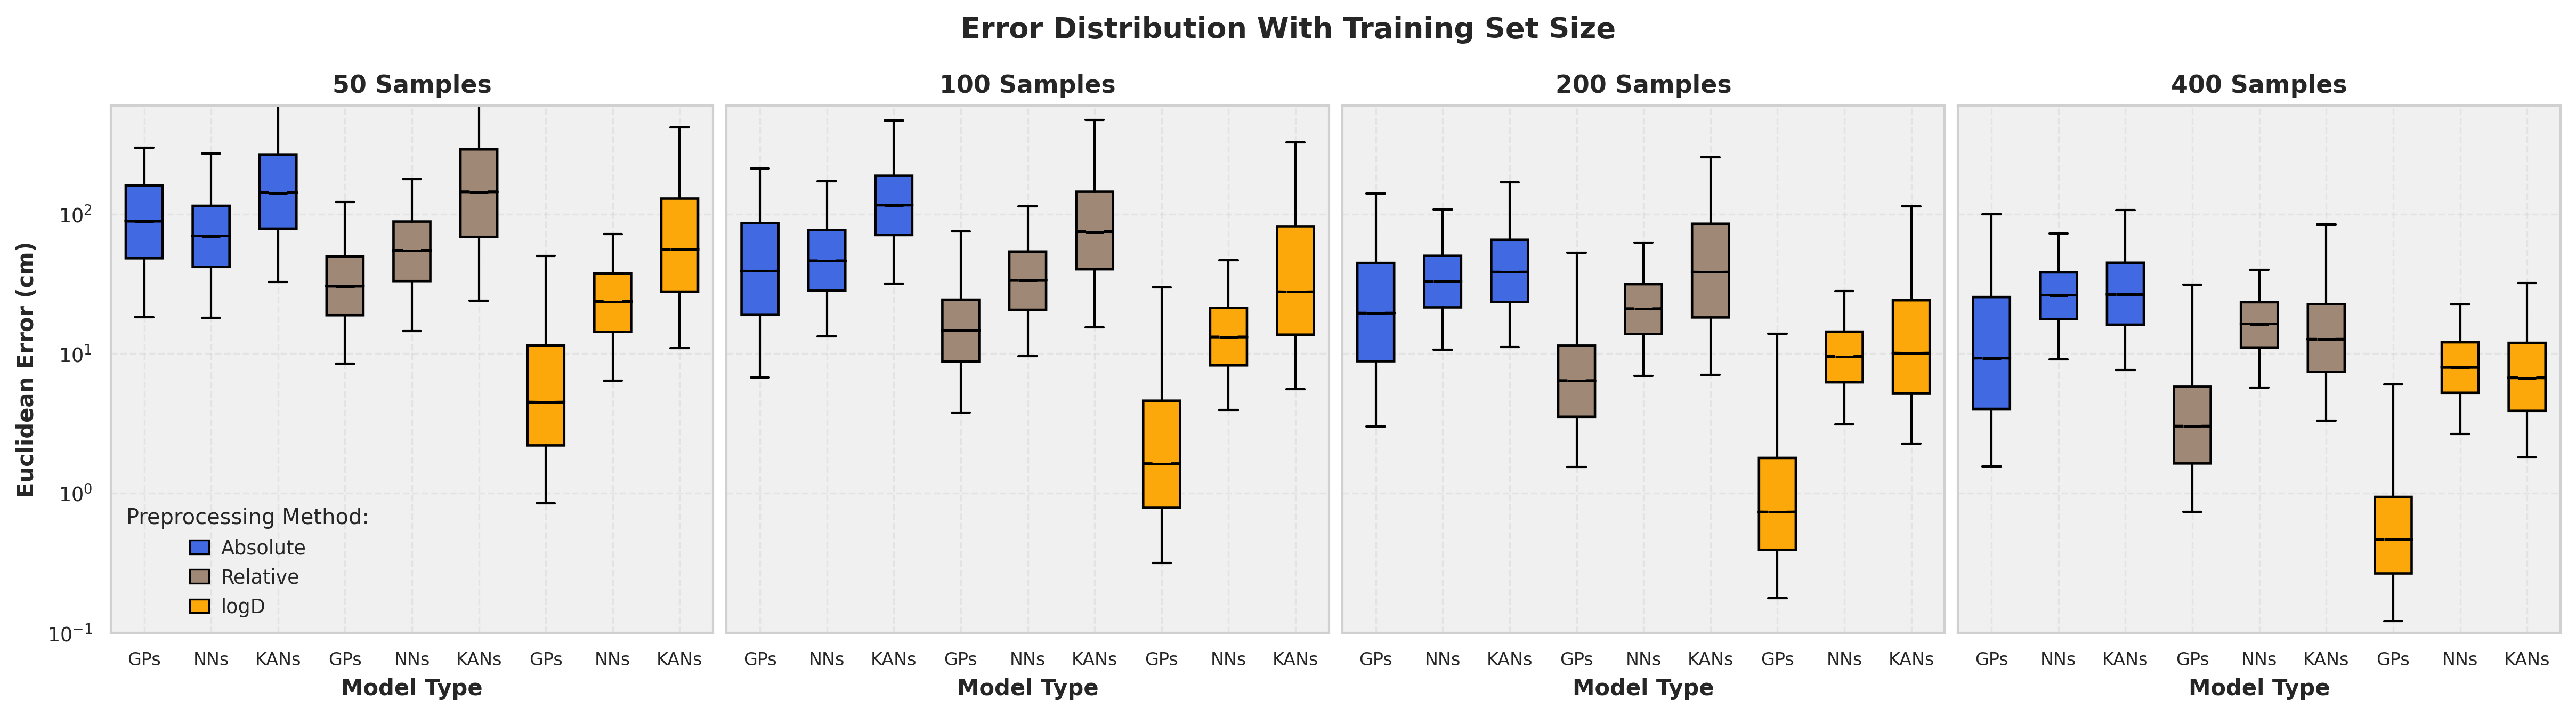

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── visual style ──────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── data definitions ─────────────────────────────────────────────────────
GND_PATH = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
N_LIST   = [50, 100, 200, 400]                     # training-set sizes

REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}

MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}

COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}

PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

# ─── helpers ───────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    """Euclidean distance (m) → convert later to centimetres."""
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def collect_errors(model, rep, n_samples, seeds=range(10)):
    """Load all seeds, return 1-D array of errors in **centimetres**."""
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in seeds:
        fn   = base / PATTERNS[(model, rep)].format(n=n_samples, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(fn)) * 100.0)  # m → cm
    return np.concatenate(errs)

# ─── plot ──────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 4, figsize=(16, 4),
                        sharey=True, constrained_layout=True)

for ax, N in zip(axs, N_LIST):

    # assemble data
    box_data, box_labels = [], []
    for rep in REPRESENTATIONS:
        for mod in MODELS:
            box_data.append(collect_errors(mod, rep, N))
            box_labels.append(MODEL_NAME[mod])

    # draw box-plot
    bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                    patch_artist=True, widths=0.55)

    # colour + outline
    for i, box in enumerate(bp["boxes"]):
        rep  = REPRESENTATIONS[i // len(MODELS)]
        fill = COLOR_MAP[rep]
        box.set(facecolor=fill, edgecolor="black", linewidth=1.1)
        for item in ("whiskers", "caps"):
            bp[item][2*i  ].set_color("black")
            bp[item][2*i+1].set_color("black")
    for med in bp["medians"]:
        med.set_color("black"); med.set_linewidth(1.2)

    # axis settings – log scale 10⁻¹ → 10³  (0.1 cm → 1000 cm)
    ax.set_facecolor(AX_BG)
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 6e2)                        # 0.1 cm to 600 cm
    ax.set_yticks([1e2, 1e1, 1e0, 1e-1])          # 100, 10, 1, 0.1 cm
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
    )

    ax.set_xticks(np.arange(1, len(box_labels) + 1))
    ax.set_xticklabels(box_labels, fontsize=8)
    ax.set_title(f"{N} Samples", fontsize=11, fontweight="bold")
    ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")

# shared y-label
axs[0].set_ylabel("Euclidean Error (cm)", fontsize=10, fontweight="bold")

# legend – bottom-left inside the first axis, left-aligned handles/text
legend_patches = [Patch(facecolor=c, edgecolor="black", label=REP_NAME[r])
                  for r, c in COLOR_MAP.items()]
axs[0].legend(handles=legend_patches,
              title="Preprocessing Method:",
              frameon=False,
              loc="lower left",
              handlelength=1.0, handletextpad=0.6, borderpad=0.3)

fig.suptitle("Error Distribution With Training Set Size",
             fontsize=13, fontweight="bold", y=1.08)

fig.savefig("model_error_by_samples_cm.svg", format="svg", dpi=400)
plt.show()


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── style (unchanged) ───────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── constants (paths, mappings) ──────────────────────────────────────────
GND_PATH  = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
SEEDS     = range(10)

REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}

MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}

COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}

PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

AXIS_ORDER   = ["X", "Y", "Z"]
HATCH_MAP    = {"X": "", "Y": "///", "Z": "\\\\"}

# ─── helpers ──────────────────────────────────────────────────────────────
df_gnd = pd.read_csv(GND_PATH)[AXIS_ORDER]

def axis_errors(model, rep, axis, n_samples):
    """
    Absolute error array for one axis in **centimetres**.        # ← cm change
    """
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in SEEDS:
        fn = base / PATTERNS[(model, rep)].format(n=n_samples, seed=s)
        errs.append(np.abs(df_gnd[axis] - pd.read_csv(fn)[axis]).values * 100.0)  # m → cm
    return np.concatenate(errs)

def make_rep_figure(n_samples):
    """Create and save the three-panel ‘by representation’ figure for a given n."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 4),
                            sharey=True, constrained_layout=True)

    for ax, rep in zip(axs, REPRESENTATIONS):
        box_data, hatch_list, box_labels = [], [], []

        for mod in MODELS:                 # GPs, NNs, KANs
            for axis in AXIS_ORDER:        # X, Y, Z
                box_data.append(axis_errors(mod, rep, axis, n_samples))
                hatch_list.append(HATCH_MAP[axis])
            box_labels.append(MODEL_NAME[mod])

        bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                        patch_artist=True, widths=0.6)

        for i, box in enumerate(bp["boxes"]):
            box.set(facecolor=COLOR_MAP[rep],
                    edgecolor="black", linewidth=1.1,
                    hatch=hatch_list[i])
            for part in ("whiskers", "caps"):
                bp[part][2*i  ].set_color("black")
                bp[part][2*i+1].set_color("black")
        for med in bp["medians"]:
            med.set_color("black"); med.set_linewidth(1.2)

        ax.set_facecolor(AX_BG)
        ax.set_yscale("log")
        ax.set_ylim(1e-2, 1e2)                  # 0.01 cm → 100 cm   # ← cm change
        ax.set_yticks([1e2, 1e1, 1e0, 1e-1, 1e-2])
        ax.get_yaxis().set_major_formatter(
            plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
        )

        ax.set_xticks([2, 5, 8])                # centre of each model triplet
        ax.set_xticklabels(box_labels, fontsize=9)
        ax.set_title(REP_NAME[rep], fontsize=11, fontweight="bold")
        ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")

    axs[0].set_ylabel("Absolute Error (cm)", fontsize=10, fontweight="bold")  # ← cm change

    legend_patches = [Patch(facecolor="white", edgecolor="black",
                            hatch=HATCH_MAP[a], label=f"|Δ{a}|")
                      for a in AXIS_ORDER]
    axs[0].legend(handles=legend_patches, title="Coordinate Axis:",
                  frameon=False, loc="lower left")

    fig.suptitle(f"Coordinate-wise Error Distribution • n = {n_samples}",
                 fontsize=13, fontweight="bold", y=1.08)

    out_name = f"model_error_{n_samples}_samples_by_rep_cm.svg"              # ← cm change
    fig.savefig(out_name, format="svg", dpi=400)
    plt.close(fig)

# ─── main loop ────────────────────────────────────────────────────────────
for n in range(50, 1501, 50):
    print(f"Rendering n = {n} …")
    make_rep_figure(n)

print("All figures saved!")


Rendering n = 50 …
Rendering n = 100 …
Rendering n = 150 …
Rendering n = 200 …
Rendering n = 250 …
Rendering n = 300 …
Rendering n = 350 …
Rendering n = 400 …
Rendering n = 450 …
Rendering n = 500 …
Rendering n = 550 …
Rendering n = 600 …
Rendering n = 650 …
Rendering n = 700 …
Rendering n = 750 …
Rendering n = 800 …
Rendering n = 850 …
Rendering n = 900 …
Rendering n = 950 …
Rendering n = 1000 …
Rendering n = 1050 …
Rendering n = 1100 …
Rendering n = 1150 …
Rendering n = 1200 …
Rendering n = 1250 …
Rendering n = 1300 …
Rendering n = 1350 …
Rendering n = 1400 …
Rendering n = 1450 …
Rendering n = 1500 …
All figures saved!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── styling ───────────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ── constants ─────────────────────────────────────────────────────────────
GND_PATH     = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
MODEL_DIR    = "./predictions/gps_log_d"                # log-d GP folder

NOISE_LEVELS = [0.0, 6e-06, 1.9e-05, 6e-05, 1.9e-04]
X_TICK_LABEL = [
    "∞ dB SNR (no noise)",
    "60 dB SNR",
    "50 dB SNR",
    "40 dB SNR",
    "30 dB SNR",
]

FILE_PATTERN = "rss_n={n}_noise={noise}_seed={seed}.csv"
LOGD_COLOR   = (252/255, 167/255, 10/255)

# ── helpers ───────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    """Return Euclidean distance in metres; caller handles conversion."""
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def load_errors(n_train, noise):
    """
    Gather errors for one training size & noise level
    → returns 1-D array **in centimetres**.                       # ← cm change
    """
    seeds = range(10) if noise == 0.0 else [0]
    errs  = []
    base  = Path(MODEL_DIR)
    for s in seeds:
        f = base / FILE_PATTERN.format(n=n_train, noise=noise, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(f)) * 100.0)  # m → cm
    return np.concatenate(errs)

# ── main loop over n = 50 … 1500 ──────────────────────────────────────────
for n_train in range(50, 1501, 50):

    # gather errors for every noise level
    box_data = [load_errors(n_train, nz) for nz in NOISE_LEVELS]

    # ─ plot ─
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.set_facecolor(AX_BG)

    bp = ax.boxplot(
        box_data, notch=True, whis=[5, 95], showfliers=False,
        patch_artist=True, widths=0.6
    )

    for box, med in zip(bp["boxes"], bp["medians"]):
        box.set(facecolor=LOGD_COLOR, edgecolor="black", linewidth=1.1)
        med.set_color("black"); med.set_linewidth(1.2)
    for item in ("whiskers", "caps"):
        for line in bp[item]:
            line.set_color("black")

    # log y-axis 10⁻¹ → 10²  (0.1 cm → 100 cm)                     # ← cm change
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1e2)
    ax.set_yticks([1e2, 1e1, 1e0, 1e-1])
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
    )

    ax.set_xticks(np.arange(1, len(X_TICK_LABEL) + 1))
    ax.set_xticklabels(X_TICK_LABEL, fontsize=9)
    ax.set_xlabel("Channel Signal-to-Noise Ratio", fontsize=11, fontweight="bold")
    ax.set_ylabel("Euclidean Error (cm)",          fontsize=11, fontweight="bold")  # ← cm change
    ax.set_title(f"Noise Impact on logD GP Model  (n = {n_train})",
                 fontsize=13, fontweight="bold")

    # save SVG
    out_name = f"gp_logd_noise_impact_n_{n_train}_cm.svg"                # ← cm change
    fig.savefig(out_name, format="svg", dpi=400)
    plt.close(fig)     # keep memory usage low

print("✓ All figures saved as gp_logd_noise_impact_n_<n>_cm.svg")


✓ All figures saved as gp_logd_noise_impact_n_<n>_cm.svg


In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

# ---------- constants ---------- #
GND_PATH = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
SEEDS = range(10)
N_VALUES = range(50, 1501, 50)

REPRESENTATIONS = ["absolute", "relative", "log_d"]
MODELS = ["gps", "nns", "KANs"]

PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

def compute_difference_norms(df1, df2):
    return np.linalg.norm(df1[["X","Y","Z"]].values - df2[["X","Y","Z"]].values, axis=1)

# guard ground-truth exists
if not Path(GND_PATH).exists():
    raise FileNotFoundError("Ground‑truth file not found. Please check GND_PATH.")

df_gnd = pd.read_csv(GND_PATH)[["X","Y","Z"]]

records = []

for n in N_VALUES:
    for model in MODELS:
        for rep in REPRESENTATIONS:
            stats = {k: [] for k in ["mean", "median", "p90", "p95", "max"]}
            base = Path(f"./predictions/{model}_{rep}")
            patt = PATTERNS[(model, rep)]
            for seed in SEEDS:
                fp = base / patt.format(n=n, seed=seed)
                if not fp.exists():
                    continue
                errs_cm = compute_difference_norms(df_gnd, pd.read_csv(fp)) * 100.0
                stats["mean"].append(errs_cm.mean())
                stats["median"].append(np.median(errs_cm))
                stats["p90"].append(np.percentile(errs_cm, 90))
                stats["p95"].append(np.percentile(errs_cm, 95))
                stats["max"].append(errs_cm.max())
            if len(stats["mean"]) == 0:
                continue
            row = {"n_train": n, "model": model, "representation": rep}
            for k, v in stats.items():
                v = np.asarray(v, float)
                row[f"{k}_cm"]     = v.mean()
                row[f"{k}_std_cm"] = v.std(ddof=1)
            records.append(row)

df_stats = pd.DataFrame.from_records(records)
df_stats.sort_values(["n_train", "model", "representation"], inplace=True)

# ensure output directory exists
# ---------- after df_stats has been computed ---------- #

out_dir = Path("./table_format_data")
out_dir.mkdir(parents=True, exist_ok=True)

for n, sub_df in df_stats.groupby("n_train"):
    # build "value ± σ" strings on-the-fly
    tidy = sub_df.copy()
    for stat in ["mean", "median", "p90", "p95", "max"]:
        tidy[stat] = (
            tidy[f"{stat}_cm"].round(2).astype(str) +
            " ± " +
            tidy[f"{stat}_std_cm"].round(2).astype(str)
        )
        tidy.drop([f"{stat}_cm", f"{stat}_std_cm"], axis=1, inplace=True)

    # choose the order you like
    cols = ["model", "representation", "mean", "median", "p90", "p95", "max"]
    tidy = tidy[cols]

    out_csv = out_dir / f"stats_cm_n_{n:04d}.csv"
    tidy.to_csv(out_csv, index=False)
    print(f"  • saved {out_csv}")


  • saved table_format_data/stats_cm_n_0050.csv
  • saved table_format_data/stats_cm_n_0100.csv
  • saved table_format_data/stats_cm_n_0150.csv
  • saved table_format_data/stats_cm_n_0200.csv
  • saved table_format_data/stats_cm_n_0250.csv
  • saved table_format_data/stats_cm_n_0300.csv
  • saved table_format_data/stats_cm_n_0350.csv
  • saved table_format_data/stats_cm_n_0400.csv
  • saved table_format_data/stats_cm_n_0450.csv
  • saved table_format_data/stats_cm_n_0500.csv
  • saved table_format_data/stats_cm_n_0550.csv
  • saved table_format_data/stats_cm_n_0600.csv
  • saved table_format_data/stats_cm_n_0650.csv
  • saved table_format_data/stats_cm_n_0700.csv
  • saved table_format_data/stats_cm_n_0750.csv
  • saved table_format_data/stats_cm_n_0800.csv
  • saved table_format_data/stats_cm_n_0850.csv
  • saved table_format_data/stats_cm_n_0900.csv
  • saved table_format_data/stats_cm_n_0950.csv
  • saved table_format_data/stats_cm_n_1000.csv
  • saved table_format_data/stats_cm_n_1

In [10]:
# ── build compact p95 summary table ──────────────────────────────────────
TARGET_NS   = [50, 100, 200, 400]               # columns you want
summary_rows = []

for model in MODELS:
    for rep in REPRESENTATIONS:
        row = {"model": model, "representation": rep}
        for n in TARGET_NS:
            rec = df_stats[
                (df_stats.n_train == n) &
                (df_stats.model == model) &
                (df_stats.representation == rep)
            ]
            if rec.empty:
                row[f"n{n}"] = "-"             # missing data placeholder
            else:
                mu = rec["p95_cm"].iat[0]
                sd = rec["p95_std_cm"].iat[0]
                row[f"n{n}"] = f"{mu:.2f} ± {sd:.2f}"
        summary_rows.append(row)

df_p95 = pd.DataFrame(summary_rows)

# preferred column order
df_p95 = df_p95[["model", "representation"] + [f"n{n}" for n in TARGET_NS]]

# ── write CSV ─────────────────────────────────────────────────────────────
out_dir = Path("./table_format_data")
out_dir.mkdir(parents=True, exist_ok=True)

p95_csv = out_dir / "p95_cm_summary.csv"
df_p95.to_csv(p95_csv, index=False)
print(f"✓ saved {p95_csv}")


✓ saved table_format_data/p95_cm_summary.csv
